# Train Arrhenius NN

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cantera as ct

from models.ArrheniusNN import GlobalArrheniusSurrogate

In [2]:
gas = ct.Solution("gri30.yaml")
species_names = gas.species_names
molecular_weights = np.array(gas.molecular_weights, dtype=np.float32)

df = pd.read_csv("../data/raw/mixed_data.csv")
Y_cols = [f"Y_{name}" for name in species_names]
Ydot_cols = [f"Ydot_{name}" for name in species_names]

T = df["T"].to_numpy(dtype=np.float32)
rho_total = df["rho"].to_numpy(dtype=np.float32)
Y = df[Y_cols].to_numpy(dtype=np.float32)
Ydot = df[Ydot_cols].to_numpy(dtype=np.float32)

rho_species = Y * rho_total[:, None]
wdot = Ydot * rho_total[:, None] / molecular_weights[None, :]

rng = np.random.default_rng(0)
idx = rng.permutation(len(T))
n_val = int(0.2 * len(T))
val_idx, train_idx = idx[:n_val], idx[n_val:]

T_train, rho_train, wdot_train = T[train_idx], rho_species[train_idx], wdot[train_idx]
T_val, rho_val, wdot_val = T[val_idx], rho_species[val_idx], wdot[val_idx]

print(f"Train: {len(T_train)}, Val: {len(T_val)}")

Train: 80000, Val: 20000


In [3]:
T_train_t = torch.tensor(T_train)
rho_train_t = torch.tensor(rho_train)
wdot_train_t = torch.tensor(wdot_train)
T_val_t = torch.tensor(T_val)
rho_val_t = torch.tensor(rho_val)
wdot_val_t = torch.tensor(wdot_val)

target_log_mag_train = torch.log(torch.abs(wdot_train_t) + 1e-30)
target_sign_train = torch.sign(wdot_train_t)
target_log_mag_val = torch.log(torch.abs(wdot_val_t) + 1e-30)
target_sign_val = torch.sign(wdot_val_t)

model = GlobalArrheniusSurrogate(n_species=len(species_names), molecular_weights=molecular_weights,
                                   hidden=512, n_layers=8)

model.set_input_norm(T_ref=T_train.mean(), rho_ref=rho_train.mean())


In [4]:
# gradient sanity check BEFORE training -- must be nonzero, or nothing below will work
log_mag_pred, sign_pred, info = model(T_train_t[:256], rho_train_t[:256])

mag_loss = nn.functional.mse_loss(log_mag_pred, target_log_mag_train[:256])
sign_loss = nn.functional.mse_loss(sign_pred, target_sign_train[:256])
loss = mag_loss + sign_loss + 1e-3 * info["order_sum"].mean()
loss.backward()

for name, p in model.named_parameters():
    g = p.grad
    print(name, "grad norm:", g.norm().item() if g is not None else None)

print("order_sum mean at init:", info["order_sum"].mean().item())
model.zero_grad()

input_layer.weight grad norm: 4251724.5
input_layer.bias grad norm: 85732.1796875
blocks.0.linear.weight grad norm: 3890030.75
blocks.0.linear.bias grad norm: 60562.51953125
blocks.1.linear.weight grad norm: 4573103.5
blocks.1.linear.bias grad norm: 64142.73046875
blocks.2.linear.weight grad norm: 4959663.5
blocks.2.linear.bias grad norm: 60213.703125
blocks.3.linear.weight grad norm: 5167493.0
blocks.3.linear.bias grad norm: 53006.26953125
blocks.4.linear.weight grad norm: 5810389.5
blocks.4.linear.bias grad norm: 49913.91796875
blocks.5.linear.weight grad norm: 6584927.5
blocks.5.linear.bias grad norm: 45896.52734375
output_layer.weight grad norm: 69753728.0
output_layer.bias grad norm: 405730.1875
order_sum mean at init: 26.71364974975586


In [5]:
def loss_fn(log_mag_pred, sign_pred, log_mag_true, sign_true, order_sum, sparsity_weight=1e-3):
    mag_loss = nn.functional.mse_loss(log_mag_pred, log_mag_true)
    sign_loss = nn.functional.mse_loss(sign_pred, sign_true)
    sparsity_loss = order_sum.mean()
    return mag_loss + sign_loss + sparsity_weight * sparsity_loss


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n = len(T_train_t)
batch_size = 256
epochs = 300

for epoch in range(epochs):
    perm = torch.randperm(n)
    total_loss = 0.0
    for i in range(0, n, batch_size):
        idx_b = perm[i:i + batch_size]
        log_mag_pred, sign_pred, info = model(T_train_t[idx_b], rho_train_t[idx_b])
        loss = loss_fn(log_mag_pred, sign_pred,
                        target_log_mag_train[idx_b], target_sign_train[idx_b],
                        info["order_sum"])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx_b)

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            log_mag_val, sign_val, val_info = model(T_val_t, rho_val_t)
            val_loss = loss_fn(log_mag_val, sign_val,
                                target_log_mag_val, target_sign_val,
                                val_info["order_sum"]).item()
        print(f"Epoch {epoch+1}: train_loss={total_loss/n:.5e}, val_loss={val_loss:.5e}, "
              f"order_sum(mean)={info['order_sum'].mean().item():.2f}")

Epoch 5: train_loss=6.06989e+02, val_loss=8.80519e+02, order_sum(mean)=5.35
Epoch 10: train_loss=7.33098e+02, val_loss=3.55477e+02, order_sum(mean)=4.90
Epoch 15: train_loss=3.37039e+02, val_loss=3.13238e+02, order_sum(mean)=4.54
Epoch 20: train_loss=1.44169e+03, val_loss=3.41590e+02, order_sum(mean)=6.57
Epoch 25: train_loss=6.14316e+02, val_loss=1.35301e+03, order_sum(mean)=6.97
Epoch 30: train_loss=5.07141e+02, val_loss=9.97510e+02, order_sum(mean)=8.11
Epoch 35: train_loss=9.21715e+02, val_loss=4.15504e+02, order_sum(mean)=7.81
Epoch 40: train_loss=1.41898e+03, val_loss=4.98986e+02, order_sum(mean)=8.37
Epoch 45: train_loss=7.29407e+02, val_loss=1.59005e+04, order_sum(mean)=12.46
Epoch 50: train_loss=6.49853e+02, val_loss=4.14059e+02, order_sum(mean)=7.83
Epoch 55: train_loss=6.11031e+02, val_loss=5.30318e+02, order_sum(mean)=8.16
Epoch 60: train_loss=4.04806e+03, val_loss=5.22555e+02, order_sum(mean)=8.18
Epoch 65: train_loss=1.46843e+03, val_loss=2.43398e+03, order_sum(mean)=7.81

A: tensor([13.4113, 13.5768, 13.8152, 14.8967, 18.2439])
b: tensor([-5.4017, -5.2623, -3.3309, -1.5595,  5.6738])
Ea: tensor([39986.5195, 39986.2500, 39986.0234, 39984.2539, 39978.3711])
order_sum mean after training: 4.820641040802002


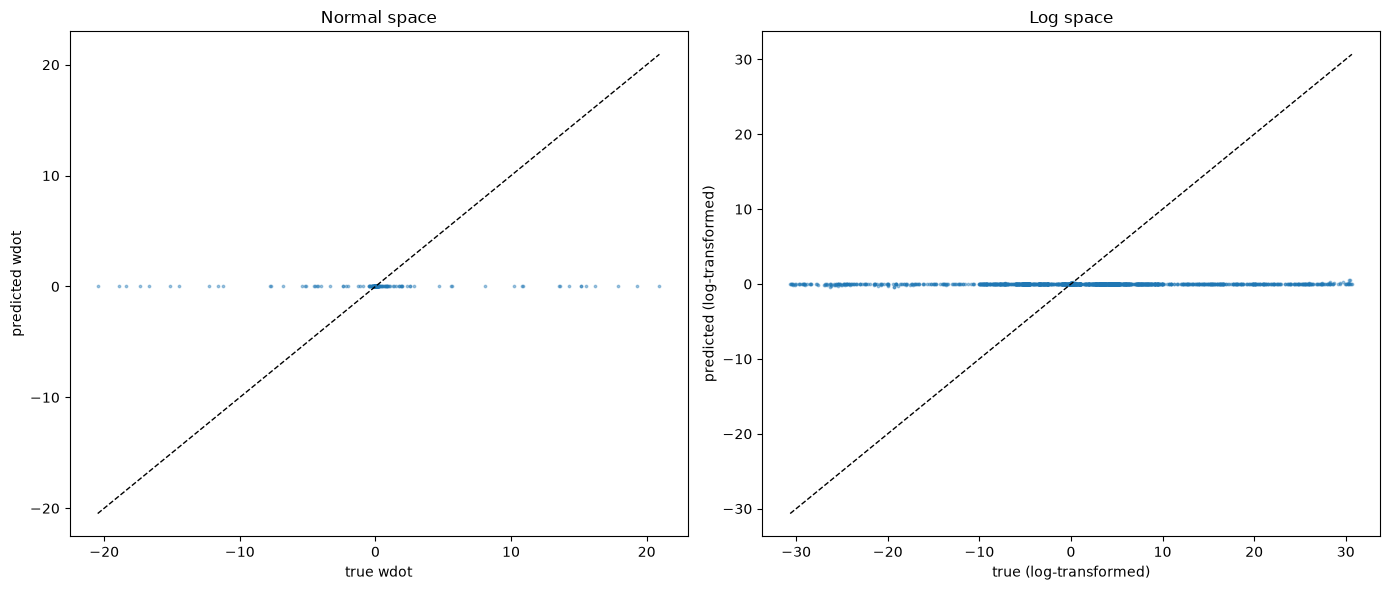

In [6]:
with torch.no_grad():
    log_mag_val, sign_val, val_info = model(T_val_t, rho_val_t)

print("A:", val_info["A"][:5])
print("b:", val_info["b"][:5])
print("Ea:", val_info["Ea"][:5])
print("order_sum mean after training:", val_info["order_sum"].mean().item())

wdot_pred_linear = val_info["wdot_linear"].numpy().flatten()
wdot_true = wdot_val_t.numpy().flatten()

n_plot = 5000
idx_plot = np.random.choice(len(wdot_true), size=n_plot, replace=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(wdot_true[idx_plot], wdot_pred_linear[idx_plot], s=3, alpha=0.4)
lims = [wdot_true[idx_plot].min(), wdot_true[idx_plot].max()]
ax[0].plot(lims, lims, 'k--', linewidth=1)
ax[0].set_xlabel("true wdot")
ax[0].set_ylabel("predicted wdot")
ax[0].set_title("Normal space")

log_true = np.sign(wdot_true[idx_plot]) * np.log1p(np.abs(wdot_true[idx_plot]) * 1e12)
log_pred = np.sign(wdot_pred_linear[idx_plot]) * np.log1p(np.abs(wdot_pred_linear[idx_plot]) * 1e12)
ax[1].scatter(log_true, log_pred, s=3, alpha=0.4)
log_lims = [log_true.min(), log_true.max()]
ax[1].plot(log_lims, log_lims, 'k--', linewidth=1)
ax[1].set_xlabel("true (log-transformed)")
ax[1].set_ylabel("predicted (log-transformed)")
ax[1].set_title("Log space")

plt.tight_layout()
plt.show()

# Training bigger model

In [ ]:
train_losses = []
val_losses = []
order_sums = []